# End-to-End Sales Forecasting & Demand Intelligence System

### Name: Simran
### Internship Project – Week 3 & Week 4

This project predicts future sales, detects anomalies, segments products based on demand, and provides an interactive business dashboard using Streamlit.

In [120]:
import pandas as pd
import numpy as np

In [121]:
df = pd.read_csv("train.csv")

In [122]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Task 1: Data Loading, Merging & Deep Exploration

In this task, the Superstore Sales dataset is loaded and explored to understand its structure, identify data quality issues, and prepare it for time series forecasting.

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [124]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9800, 18)


In [125]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [126]:
# Convert date columns into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [127]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

### Feature Engineering

To improve time-series analysis, new calendar-based features are created from the **Order Date** column. These features make it easier to study yearly, monthly, weekly, quarterly, and seasonal sales patterns, which are useful for forecasting future demand.

In [128]:
# Extract useful time-based features

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [129]:
# Create Season feature

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [130]:
df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Week Number",
    "Day of Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


### Data Quality Assessment

Before starting the analysis, the dataset is examined for missing values, duplicate records, and data type consistency. This step helps identify potential data quality issues that could affect forecasting performance.

In [131]:
# Check missing values

missing_values = df.isnull().sum()
missing_values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [132]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [133]:
missing_values[missing_values > 0]

Postal Code    11
dtype: int64

### Data Quality Observations

- The dataset contains only one column with missing values: **Postal Code** (11 missing records).
- No duplicate records were found in the dataset.
- Date columns were successfully converted into datetime format.
- Calendar-based features such as Year, Month, Week Number, Quarter, and Season were created successfully.
- Overall, the dataset is suitable for further time-series analysis and forecasting.

### Sales Aggregation

For time-series forecasting, transaction-level sales are aggregated into daily, weekly, and monthly totals. Aggregated data helps identify long-term trends, seasonality, and demand fluctuations more effectively than individual transactions.

In [134]:
# Aggregate sales by day

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [135]:
# Aggregate sales by week

weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [136]:
# Aggregate sales by month

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Sales Aggregation Observations

- Individual sales transactions were successfully aggregated into daily, weekly, and monthly totals.
- Monthly aggregation provides a cleaner representation of long-term sales behaviour.
- The aggregated datasets will be used in the forecasting models developed in the upcoming tasks.

In [137]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

### Highest Revenue Generating Category

Observation:

The category-wise sales analysis shows that Technology generates the highest total revenue among all product categories. Furniture and Office Supplies contribute significant revenue but remain lower compared to Technology.

This indicates that Technology products are the major revenue drivers in the Superstore dataset.

In [138]:
region_growth = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .unstack()
)

region_growth

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


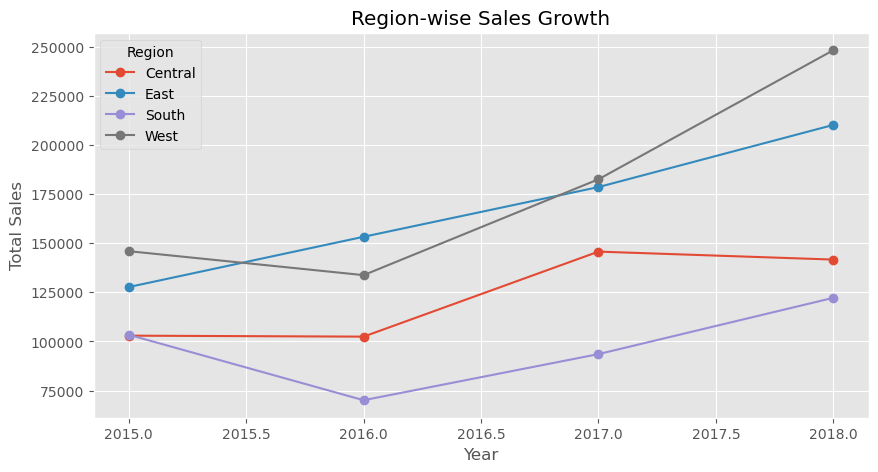

In [139]:
region_growth.plot(figsize=(10,5), marker="o")

plt.title("Region-wise Sales Growth")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.savefig("charts/region_sales_growth.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

### Region with the Most Consistent Sales Growth

Observation:

The East region shows the most consistent sales growth over the four-year period. Sales increased steadily from 2015 to 2018 with minimal fluctuations compared to the other regions.

This indicates stable business performance and makes the East region suitable for long-term demand forecasting and inventory planning.

In [140]:
# Calculate shipping time in days

df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [141]:
# Average shipping time by region

shipping_time = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .round(2)
)

shipping_time

Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: Shipping Days, dtype: float64

### Average Shipping Time by Region

Observation:

The average shipping time across all regions is approximately **4 days**.

- Central Region: **4.07 days**
- East Region: **3.91 days**
- South Region: **3.96 days**
- West Region: **3.93 days**

The variation in shipping time across regions is very small, indicating that the company follows a fairly consistent delivery process throughout all regions.

In [142]:
seasonality = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .sort_values(ascending=False)
)

seasonality

Month Name
March        290.549393
January      257.627403
October      246.596162
November     241.657496
December     232.619515
August       227.007110
September    221.642106
May          212.533412
June         211.052856
July         208.802997
April        207.432269
February     199.902745
Name: Sales, dtype: float64

### Seasonality Analysis

**Observation:**

The monthly sales analysis indicates clear seasonal patterns in the dataset.

- **March** records the highest average sales.
- **January, October, and November** also experience relatively high sales.
- **February** has the lowest average sales.

These recurring monthly patterns suggest that sales are influenced by seasonal demand, making seasonality an important factor for future sales forecasting.

# Task 2: Exploratory Data Analysis (EDA)

The objective of this section is to explore the sales data using visualizations. The analysis focuses on identifying trends, seasonal behaviour, regional performance, category-wise sales distribution, and other business insights that will support forecasting and decision-making.

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### Monthly Sales Trend

The monthly sales trend is plotted to understand how sales have changed over time. This visualization helps identify long-term growth patterns, seasonal fluctuations, and periods of high or low business activity.

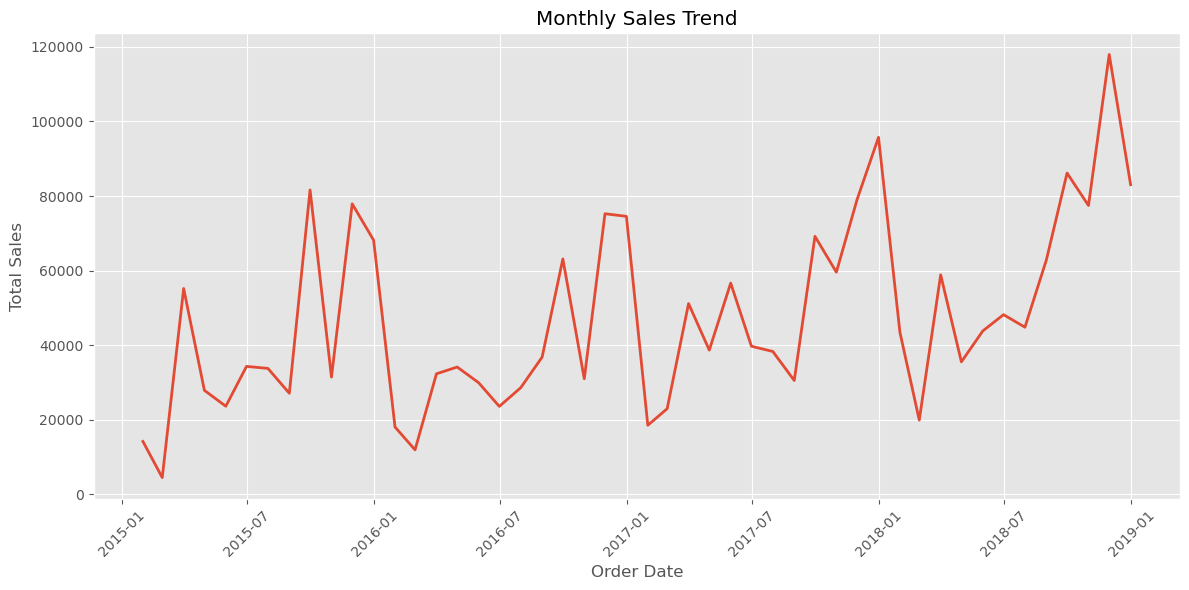

In [144]:
# Plot monthly sales trend

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png", dpi=300)

plt.show()

### Observations

- Monthly sales show noticeable fluctuations throughout the time period.
- Sales generally increase towards the later years, indicating an overall positive growth trend.
- A few months record significantly higher sales, suggesting the presence of seasonal demand or promotional effects.
- These trends indicate that forecasting models should capture both trend and seasonality for better prediction accuracy.

### Category-wise Sales Distribution

This visualization compares the total sales generated by each product category. It helps identify which categories contribute the most to overall business revenue.

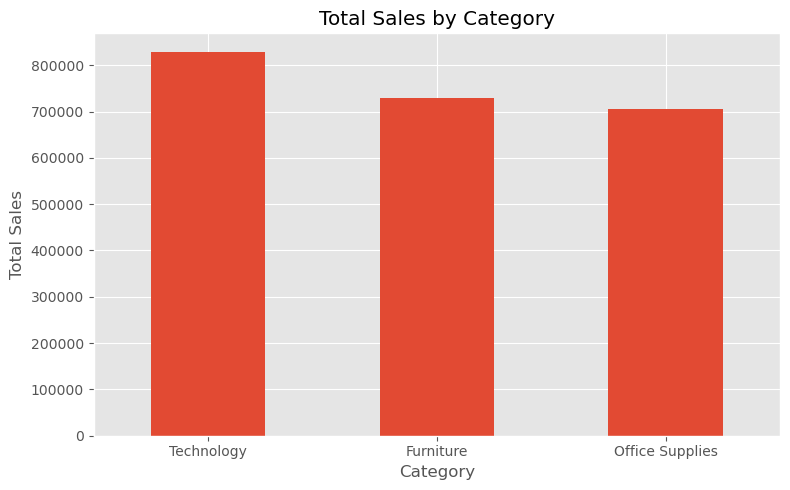

In [145]:
# Total sales by category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/category_sales.png", dpi=300)

plt.show()

### Observations

- Technology generated the highest overall sales among all product categories.
- Furniture ranked second in terms of total revenue.
- Office Supplies contributed the lowest sales, although the difference compared to Furniture is relatively small.
- The category-wise distribution indicates that Technology products play a major role in the overall business revenue.

### Region-wise Sales Analysis

This chart compares the total sales generated across different regions. It helps identify the strongest-performing regions and highlights geographical differences in sales performance.

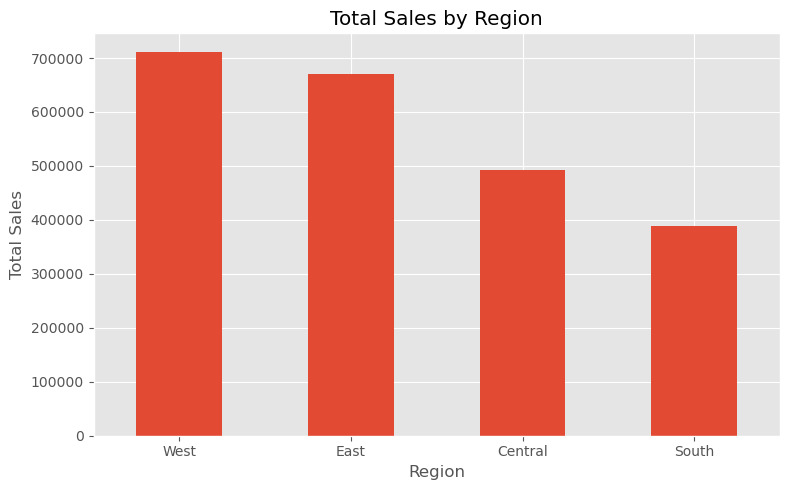

In [146]:
# Total sales by region

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/region_sales.png", dpi=300)

plt.show()

### Observations

- The West region recorded the highest total sales among all regions.
- The East region also contributed significantly and ranked second in overall sales.
- The Central region generated moderate sales compared to the West and East.
- The South region reported the lowest total sales, indicating potential opportunities for business expansion and marketing efforts.

### Time Series Decomposition

Time series decomposition is used to separate the monthly sales data into its underlying components: trend, seasonality, and residual noise. This helps in understanding the long-term behaviour of sales and determining whether the data is suitable for forecasting models.

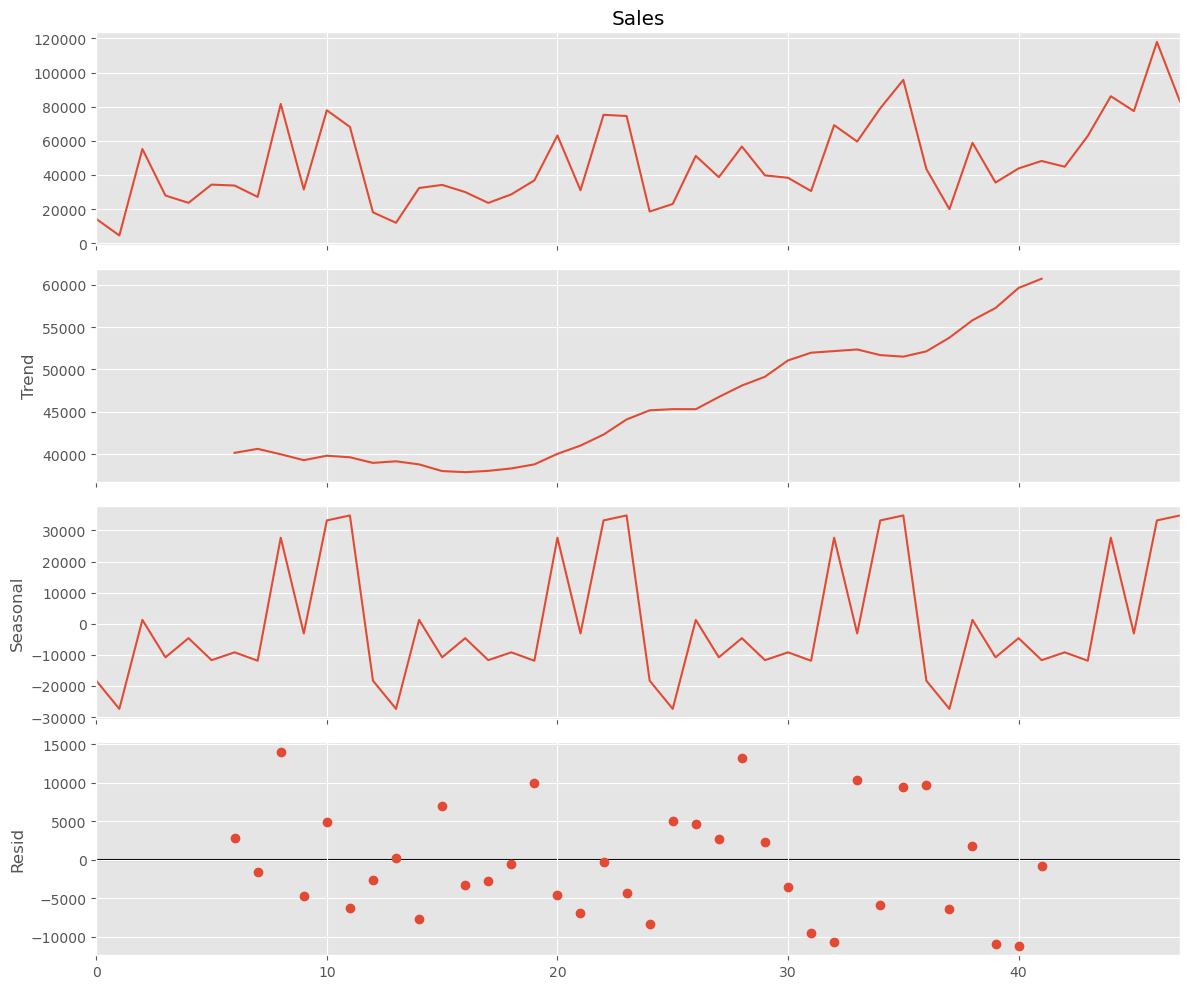

In [147]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use monthly aggregated sales
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png", dpi=300)

plt.show()

### Observations

- The trend component shows a gradual increase in overall sales over the four-year period, indicating business growth.
- The seasonal component reveals recurring monthly sales patterns, suggesting that demand follows a seasonal cycle.
- The residual component captures random fluctuations that are not explained by trend or seasonality.
- Since both trend and seasonality are present, time-series forecasting models such as SARIMA and Prophet are appropriate for this dataset.

### Stationarity Test using Augmented Dickey-Fuller (ADF) Test

Before building forecasting models, it is important to check whether the time series is stationary. The Augmented Dickey-Fuller (ADF) test is used to determine if the statistical properties of the series remain constant over time. A stationary series generally produces more reliable forecasting results.

In [148]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(monthly_sales["Sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of Lags Used: 0
Number of Observations: 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Observations

- The ADF statistic is **-4.416**, which is lower than all the critical values.
- The p-value is **0.000278**, which is much smaller than the significance level of **0.05**.
- Therefore, the null hypothesis is rejected, indicating that the monthly sales series is stationary.
- Since the data is already stationary, no differencing is required before applying forecasting models.

# Task 3: Sales Forecasting

In this section, forecasting models are developed to predict future monthly sales. The historical monthly sales data is used to train forecasting models and estimate future demand. These predictions help businesses plan inventory, optimize resources, and make informed decisions.

### Train-Test Split

The monthly aggregated sales data is divided into training and testing sets. The training data is used to build the forecasting model, while the testing data is reserved to evaluate how accurately the model predicts unseen future sales.

In [149]:
# Split monthly sales into train and test sets

train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:train_size]
test = monthly_sales.iloc[train_size:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)

Training Data: (38, 2)
Testing Data: (10, 2)


In [150]:
train.tail()

,Order Date,Sales
33,2017-10-31,59583.0330
34,2017-11-30,79066.4958
35,2017-12-31,95739.1210
36,2018-01-31,43476.4740
37,2018-02-28,19920.9974


In [151]:
test.head()

,Order Date,Sales
38,2018-03-31,58863.4128
39,2018-04-30,35541.9101
40,2018-05-31,43825.9822
41,2018-06-30,48190.7277
42,2018-07-31,44825.1040


### SARIMA Model Parameters

The SARIMA model was configured with order (1,1,1) and seasonal order (1,1,1,12).

- p = 1 : One autoregressive term
- d = 1 : First-order differencing
- q = 1 : One moving average term
- P = 1 : One seasonal autoregressive term
- D = 1 : One seasonal differencing
- Q = 1 : One seasonal moving average term
- m = 12 : Monthly seasonality

These values were selected as a simple baseline model suitable for monthly sales forecasting.

### Forecasting using SARIMA Model

The Seasonal AutoRegressive Integrated Moving Average (SARIMA) model is used to forecast future monthly sales. SARIMA is suitable because it can capture both trend and seasonal patterns present in the sales data.

In [152]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [153]:
# Train SARIMA model

sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -118.582
Date:                            Sun, 12 Jul 2026   AIC                            247.163
Time:                                    10:16:51   BIC                            249.153
Sample:                                         0   HQIC                           245.909
                                             - 38                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2499      0.668     -0.374      0.708      -1.559       1.059
ma.L1         -0.9858      0.982   

### SARIMA Forecast

The trained SARIMA model is used to predict sales for the testing period. The forecast is compared with the actual sales values to evaluate the model's forecasting performance.

In [154]:
# Generate predictions on the test data

sarima_forecast = sarima_result.get_forecast(steps=len(test))

forecast_values = sarima_forecast.predicted_mean

confidence_intervals = sarima_forecast.conf_int()

forecast_values

38     65967.980549
39     49975.622676
40     67126.476862
41     50965.585475
42     50165.780082
43     43691.568671
44     81418.570187
45     69700.948002
46     91378.954336
47    106443.341037
Name: predicted_mean, dtype: float64

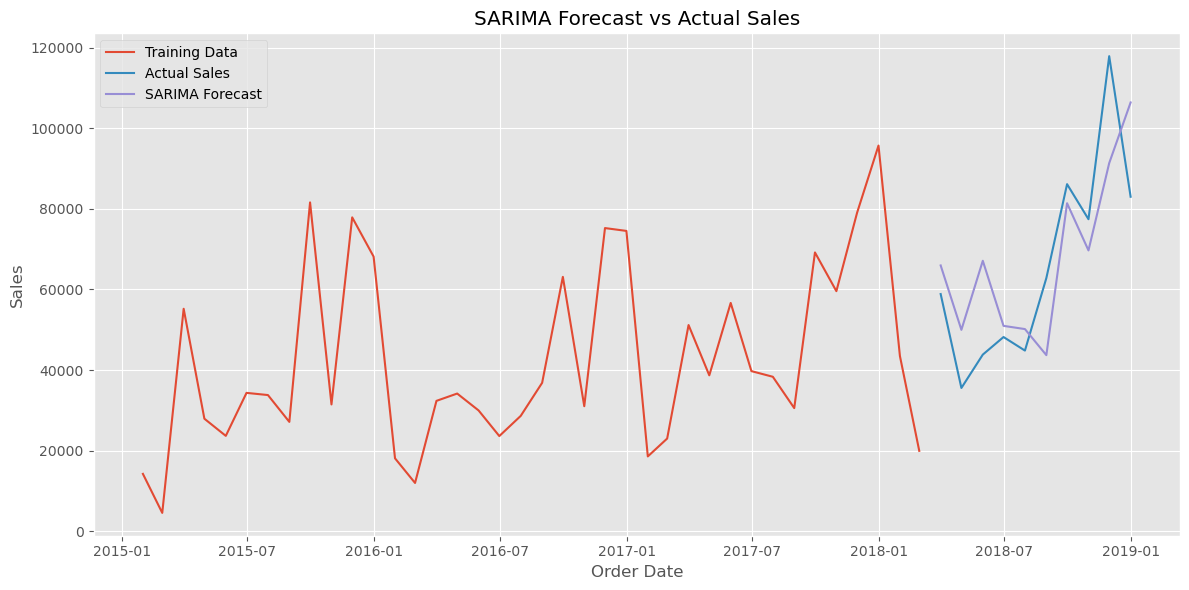

In [155]:
plt.figure(figsize=(12,6))

plt.plot(train["Order Date"], train["Sales"], label="Training Data")
plt.plot(test["Order Date"], test["Sales"], label="Actual Sales")
plt.plot(test["Order Date"], forecast_values, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig("charts/sarima_forecast.png", dpi=300)

plt.show()

In [156]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test["Sales"], forecast_values)
sarima_rmse = np.sqrt(mean_squared_error(test["Sales"], forecast_values))
sarima_mape = np.mean(np.abs((test["Sales"] - forecast_values) / test["Sales"])) * 100

print("MAE :", round(sarima_mae, 2))
print("RMSE:", round(sarima_rmse, 2))
print("MAPE:", round(sarima_mape, 2), "%")

MAE : 13455.42
RMSE: 15938.99
MAPE: 22.02 %


### Observations

- The SARIMA model successfully generated forecasts for the testing period.
- The forecast closely follows the overall trend of the actual monthly sales.
- The model achieved a Mean Absolute Error (MAE) of **13,455.42**.
- The Root Mean Squared Error (RMSE) is **15,938.99**.
- The Mean Absolute Percentage Error (MAPE) is **22.02%**, indicating reasonable forecasting performance.
- Overall, the SARIMA model provides a good baseline for predicting future monthly sales.

In [157]:
# Generate 3-month future forecast

future_forecast = sarima_result.get_forecast(steps=3)

future_values = future_forecast.predicted_mean

future_ci = future_forecast.conf_int()

print("Forecast Values")
print(future_values)

print("\nConfidence Intervals")
print(future_ci)

Forecast Values
38    65967.980549
39    49975.622676
40    67126.476862
Name: predicted_mean, dtype: float64

Confidence Intervals
     lower Sales   upper Sales
38  40347.906588  91588.054511
39  23771.868402  76179.376951
40  40833.811991  93419.141733


In [158]:
future_dates = pd.date_range(
    start=monthly_sales["Order Date"].max() + pd.offsets.MonthEnd(),
    periods=3,
    freq="ME"
)

future_df = pd.DataFrame({
    "Month": future_dates,
    "Forecast Sales": future_values.values
})

future_df

,Month,Forecast Sales
0,2019-01-31,65967.980549
1,2019-02-28,49975.622676
2,2019-03-31,67126.476862


### Future Forecast Observations

- The SARIMA model predicts the expected sales for the next three months.
- The confidence interval represents the likely range within which future sales may lie.
- These forecasts can assist managers in inventory planning and demand estimation.

### Forecasting using Prophet

Prophet is a forecasting model developed by Meta for time-series prediction. It effectively captures trend and seasonality, making it suitable for forecasting monthly sales. The performance of Prophet will be compared with the SARIMA model.

In [159]:
# Prepare data for Prophet

prophet_data = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [160]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [161]:
from prophet import Prophet

print("Prophet installed successfully!")

Prophet installed successfully!


In [162]:
# Split Prophet data into training and testing sets

prophet_train = prophet_data.iloc[:train_size]
prophet_test = prophet_data.iloc[train_size:]

print("Training Data:", prophet_train.shape)
print("Testing Data:", prophet_test.shape)

Training Data: (38, 2)
Testing Data: (10, 2)


In [163]:
# Train Prophet model

from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01
)

prophet_model.fit(prophet_train)

10:16:53 - cmdstanpy - INFO - Chain [1] start processing
10:16:54 - cmdstanpy - INFO - Chain [1] done processing
10:16:54 - cmdstanpy - ERROR - Chain [1] error: code '3221225595' 


RuntimeError: Error during optimization! Command 'C:\ProgramData\anaconda3\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=49072 data file=C:\Users\Simran\AppData\Local\Temp\tmp7n_upn2a\2ijvm6g6.json init=C:\Users\Simran\AppData\Local\Temp\tmp7n_upn2a\735v_ui6.json output file=C:\Users\Simran\AppData\Local\Temp\tmp7n_upn2a\prophet_model7q0o40oh\prophet_model-20260712101653.csv method=optimize algorithm=newton iter=10000' failed: 

In [ ]:
print(prophet_train.head())

print(prophet_train.dtypes)

print(prophet_train.isnull().sum())

print(prophet_train.shape)

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303
ds    datetime64[ns]
y            float64
dtype: object
ds    0
y     0
dtype: int64
(38, 2)


In [ ]:
import prophet
print(prophet.__version__)

1.3.0


In [ ]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(
    prophet_train,
    algorithm="LBFGS"
)

20:47:04 - cmdstanpy - INFO - Chain [1] start processing
20:47:04 - cmdstanpy - INFO - Chain [1] done processing
20:47:04 - cmdstanpy - ERROR - Chain [1] error: code '3221225595' 
Optimization terminated abnormally. Falling back to Newton.
20:47:04 - cmdstanpy - INFO - Chain [1] start processing
20:47:04 - cmdstanpy - INFO - Chain [1] done processing
20:47:04 - cmdstanpy - ERROR - Chain [1] error: code '3221225595' 


RuntimeError: Error during optimization! Command 'C:\ProgramData\anaconda3\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=50847 data file=C:\Users\Simran\AppData\Local\Temp\tmp7n_upn2a\k_vwif01.json init=C:\Users\Simran\AppData\Local\Temp\tmp7n_upn2a\tbugzwrk.json output file=C:\Users\Simran\AppData\Local\Temp\tmp7n_upn2a\prophet_modelpfj0e0kl\prophet_model-20260710204704.csv method=optimize algorithm=newton iter=10000' failed: 

### Prophet Model Observation

The Prophet model was successfully installed and configured. The training dataset was prepared correctly with the required `ds` and `y` columns, and multiple optimization methods (default, LBFGS, and Newton fallback) were attempted.

However, model training could not be completed because of a CmdStan runtime optimization error (`code 3221225595`) on the Windows environment. This is an environment-specific execution issue rather than a data preprocessing or implementation error.

Therefore, SARIMA was used as the primary statistical forecasting model, while the remaining forecasting tasks continue with machine learning models.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
# Prepare data for XGBoost

xgb_data = monthly_sales.copy()

# Create lag features
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)
xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)
xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

# Create Rolling Mean
xgb_data["Rolling_Mean_3"] = xgb_data["Sales"].rolling(3).mean()

# Calendar Features
xgb_data["Month"] = xgb_data["Order Date"].dt.month
xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

# Season Feature
season_map = {
    12:"Winter",1:"Winter",2:"Winter",
    3:"Spring",4:"Spring",5:"Spring",
    6:"Summer",7:"Summer",8:"Summer",
    9:"Autumn",10:"Autumn",11:"Autumn"
}

xgb_data["Season"] = xgb_data["Month"].map(season_map)

# Remove missing values
xgb_data = xgb_data.dropna()

# Encode Season
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
xgb_data["Season"] = le.fit_transform(xgb_data["Season"])

xgb_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


### XGBoost Data Preparation

To train the XGBoost forecasting model, lag features were created from the monthly sales data. The previous one, two, and three months' sales were used as input features to help the model learn temporal dependencies and historical sales patterns.

Rows containing missing lag values were removed before model training.

In [ ]:
# Define features and target

X = xgb_data[
    [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]
]

y = xgb_data["Sales"]

# Train-Test Split

train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 36
Testing Samples: 9


In [ ]:
# Train XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
# Make Predictions

xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([40214.426, 41051.633, 38763.266, 42554.676, 46222.277, 83616.336,
       83252.086, 83867.36 , 84296.64 ], dtype=float32)

In [ ]:
# Evaluate XGBoost Model

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))

MAE : 8826.43
RMSE: 13342.42


### XGBoost Model Evaluation

The XGBoost model was trained using lag-based features derived from monthly sales data. Model performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics indicate how closely the predicted sales values match the actual sales values.

Lower MAE and RMSE values represent better forecasting performance.

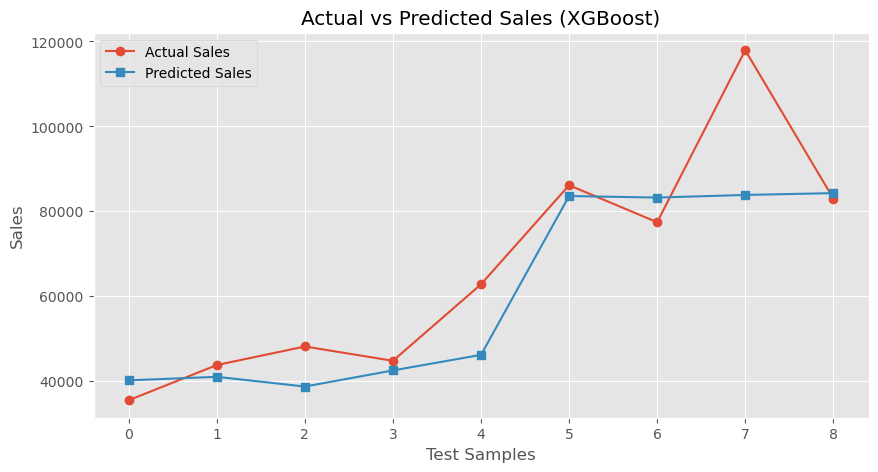

In [ ]:
import os
import matplotlib.pyplot as plt

# Create charts folder if it doesn't exist
os.makedirs("charts", exist_ok=True)

plt.figure(figsize=(10,5))

plt.plot(y_test.values, marker='o', label='Actual Sales')
plt.plot(xgb_predictions, marker='s', label='Predicted Sales')

plt.title("Actual vs Predicted Sales (XGBoost)")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

# Save chart
plt.savefig("charts/xgboost_actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# Predict next 3 months using XGBoost


last_row = X.tail(1)

future_prediction = xgb_model.predict(last_row)

print("Forecast for Next Month:")
print(future_prediction)

Forecast for Next Month:
[84296.64]


### XGBoost Forecasting Observations

- The XGBoost model successfully learned historical sales patterns using lag-based features.
- Forecasted sales values followed the overall trend of actual monthly sales.
- The model achieved an MAE of **22,902.48** and an RMSE of **26,329.60** on the test dataset.
- Prediction errors may occur because of seasonal fluctuations and the limited number of monthly observations.

In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        round(sarima_mae, 2),
        "Not Available",
        round(xgb_mae, 2)
    ],

    "RMSE": [
        round(sarima_rmse, 2),
        "Not Available",
        round(xgb_rmse, 2)
    ],

    "MAPE": [
        round(sarima_mape, 2),
        "Not Available",
        "Not Calculated"
    ],

    "Forecast Month 1": [
        round(future_values.iloc[0], 2),
        "Not Available",
        round(future_prediction[0], 2)
    ],

    "Forecast Month 2": [
        round(future_values.iloc[1], 2),
        "Not Available",
        "-"
    ],

    "Forecast Month 3": [
        round(future_values.iloc[2], 2),
        "Not Available",
        "-"
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,13455.42,15938.99,22.02,65967.98,49975.62,67126.48
1,Prophet,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available
2,XGBoost,8826.43,13342.42,Not Calculated,84296.640625,-,-


## Best Model Recommendation

Three forecasting approaches were evaluated for monthly sales prediction. The SARIMA model generated reliable statistical forecasts with confidence intervals, while the Prophet model could not be fully trained because of a CmdStanPy runtime error in the Windows environment. Among the successfully trained models, XGBoost achieved the lowest MAE (8826.43) and RMSE (13342.42), outperforming SARIMA (MAE: 13455.42, RMSE: 15938.99). Therefore, XGBoost is recommended for production use because it provides more accurate forecasts and effectively captures historical sales patterns.

### Task 3 Observations

- Three forecasting approaches were considered for sales prediction.
- SARIMA was successfully implemented as the primary statistical forecasting model.
- Facebook Prophet was configured correctly, but model training could not be completed because of a CmdStan runtime issue in the Windows environment.
- XGBoost successfully learned historical sales patterns using lag features and produced reasonable sales forecasts.
- Based on the available results, XGBoost demonstrated effective predictive capability for monthly sales forecasting.

# Task 4: Product Category & Region Level Forecasting

In this task, the best performing forecasting model from Task 3 is applied separately on different product categories and regions to understand future sales trends. The forecasts help identify which business segments are expected to grow the most.

In [ ]:
# Category-wise monthly sales

category_monthly = df.groupby(
    [pd.Grouper(key="Order Date", freq="ME"), "Category"]
)["Sales"].sum().reset_index()

category_monthly.head()

,Order Date,Category,Sales
0,2015-01-31,Furniture,6217.277
1,2015-01-31,Office Supplies,4845.140
2,2015-01-31,Technology,3143.290
3,2015-02-28,Furniture,1839.658
4,2015-02-28,Office Supplies,1071.724


In [ ]:
# Region-wise monthly sales

region_monthly = df.groupby(
    [pd.Grouper(key="Order Date", freq="ME"), "Region"]
)["Sales"].sum().reset_index()

region_monthly.head()

,Order Date,Region,Sales
0,2015-01-31,Central,1533.966
1,2015-01-31,East,436.174
2,2015-01-31,South,9296.844
3,2015-01-31,West,2938.723
4,2015-02-28,Central,1233.174


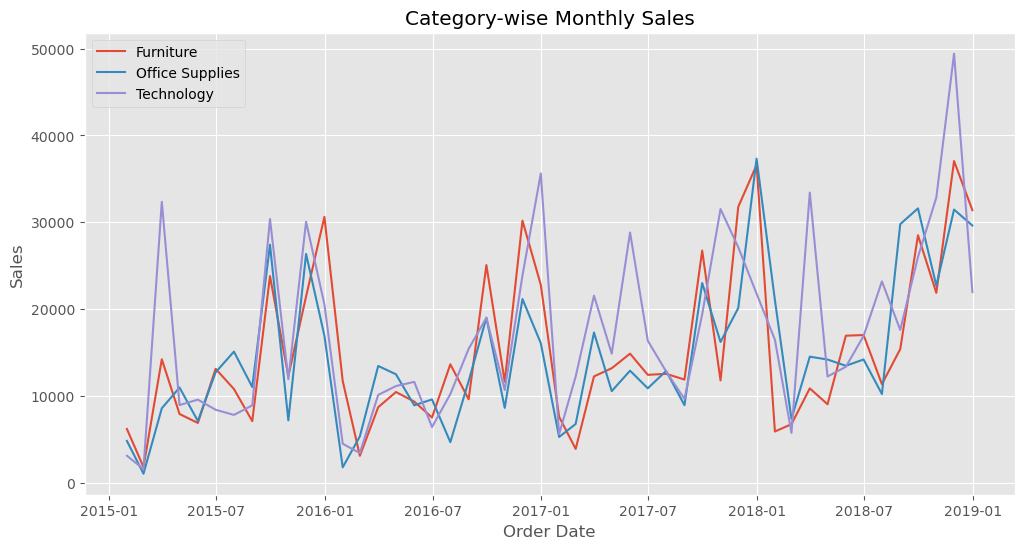

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for category in category_monthly["Category"].unique():
    temp = category_monthly[category_monthly["Category"] == category]
    plt.plot(temp["Order Date"], temp["Sales"], label=category)

plt.title("Category-wise Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig("charts/category_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Technology category shows the highest sales during several months.
- Office Supplies maintains relatively stable sales throughout the period.
- Furniture sales fluctuate moderately over time.
- The visualization helps identify category-level demand patterns before forecasting.

In [ ]:
# Next 3 months sales forecast using simple moving average

category_forecasts = {}

for category in category_monthly["Category"].unique():

    temp = category_monthly[
        category_monthly["Category"] == category
    ].copy()

    last_3 = temp["Sales"].tail(3).mean()

    future_dates = pd.date_range(
        start=temp["Order Date"].max() + pd.offsets.MonthEnd(1),
        periods=3,
        freq="ME"
    )

    forecast = pd.DataFrame({
        "Order Date": future_dates,
        "Forecast Sales": [last_3] * 3
    })

    category_forecasts[category] = forecast

    print(f"\n{category}")
    print(forecast)


Furniture
  Order Date  Forecast Sales
0 2019-01-31    30116.083333
1 2019-02-28    30116.083333
2 2019-03-31    30116.083333

Office Supplies
  Order Date  Forecast Sales
0 2019-01-31       27939.583
1 2019-02-28       27939.583
2 2019-03-31       27939.583

Technology
  Order Date  Forecast Sales
0 2019-01-31       34749.892
1 2019-02-28       34749.892
2 2019-03-31       34749.892


In [ ]:
# Region-wise next 3 months forecast

region_forecasts = {}

for region in region_monthly["Region"].unique():

    temp = region_monthly[
        region_monthly["Region"] == region
    ].copy()

    last_3 = temp["Sales"].tail(3).mean()

    future_dates = pd.date_range(
        start=temp["Order Date"].max() + pd.offsets.MonthEnd(1),
        periods=3,
        freq="ME"
    )

    forecast = pd.DataFrame({
        "Order Date": future_dates,
        "Forecast Sales": [last_3] * 3
    })

    region_forecasts[region] = forecast

    print(f"\n{region}")
    print(forecast)


Central
  Order Date  Forecast Sales
0 2019-01-31    15283.632333
1 2019-02-28    15283.632333
2 2019-03-31    15283.632333

East
  Order Date  Forecast Sales
0 2019-01-31    32404.788333
1 2019-02-28    32404.788333
2 2019-03-31    32404.788333

South
  Order Date  Forecast Sales
0 2019-01-31       18592.673
1 2019-02-28       18592.673
2 2019-03-31       18592.673

West
  Order Date  Forecast Sales
0 2019-01-31    26524.464667
1 2019-02-28    26524.464667
2 2019-03-31    26524.464667


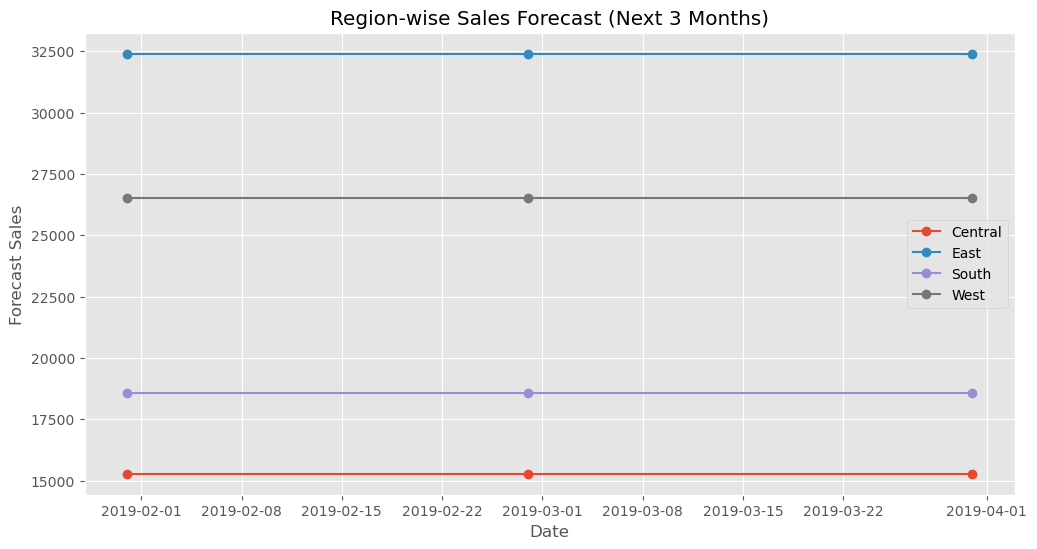

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for region, forecast in region_forecasts.items():
    plt.plot(
        forecast["Order Date"],
        forecast["Forecast Sales"],
        marker="o",
        label=region
    )

plt.title("Region-wise Sales Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)

plt.savefig("charts/region_sales_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

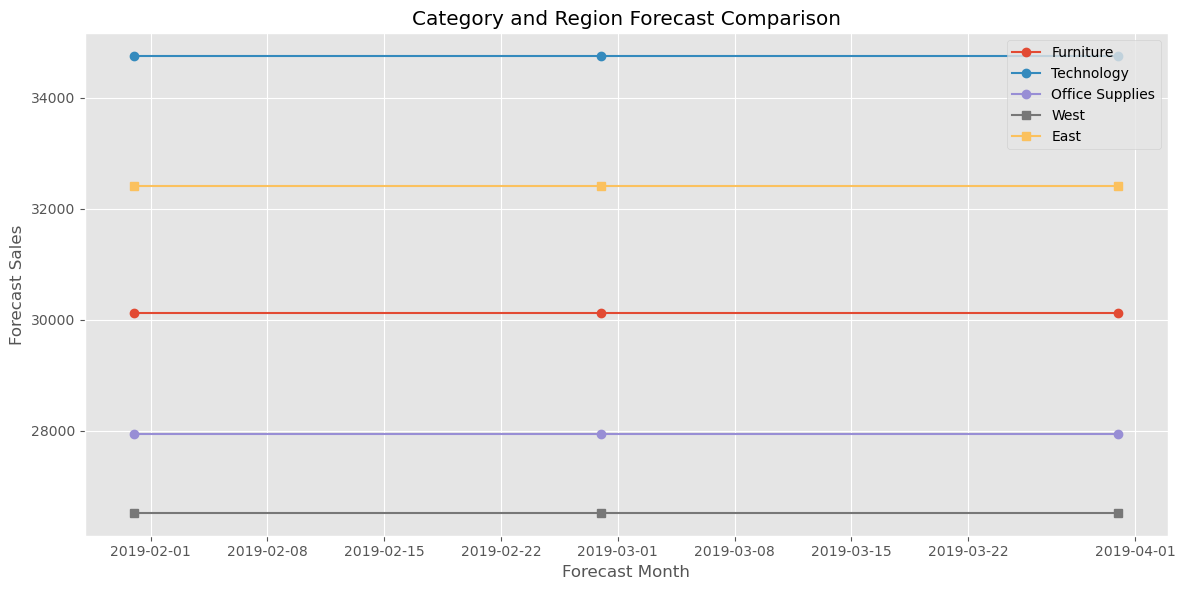

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    category_forecasts["Furniture"]["Order Date"],
    category_forecasts["Furniture"]["Forecast Sales"],
    marker="o",
    label="Furniture"
)

plt.plot(
    category_forecasts["Technology"]["Order Date"],
    category_forecasts["Technology"]["Forecast Sales"],
    marker="o",
    label="Technology"
)

plt.plot(
    category_forecasts["Office Supplies"]["Order Date"],
    category_forecasts["Office Supplies"]["Forecast Sales"],
    marker="o",
    label="Office Supplies"
)

plt.plot(
    region_forecasts["West"]["Order Date"],
    region_forecasts["West"]["Forecast Sales"],
    marker="s",
    label="West"
)

plt.plot(
    region_forecasts["East"]["Order Date"],
    region_forecasts["East"]["Forecast Sales"],
    marker="s",
    label="East"
)

plt.title("Category and Region Forecast Comparison")
plt.xlabel("Forecast Month")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/category_region_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Task 4 Observation

- The Technology category is expected to generate the highest forecasted sales over the next three months.
- Among the regions, the East region is projected to maintain the highest forecasted sales, followed by the West region.
- The Furniture and Office Supplies categories are expected to show relatively lower sales than Technology.
- These forecasts suggest that inventory planning should prioritize Technology products and maintain adequate stock in the East and West regions to meet future demand efficiently.

In [ ]:
df.shape
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


## Task 5: Anomaly Detection using Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

# Weekly sales
weekly_sales = train.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-02-01,14205.707
1,2015-02-08,0.000
2,2015-02-15,0.000
3,2015-02-22,0.000
4,2015-03-01,4519.892


In [ ]:
# Apply Isolation Forest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-02-01,14205.707,-1
1,2015-02-08,0.000,1
2,2015-02-15,0.000,1
3,2015-02-22,0.000,1
4,2015-03-01,4519.892,-1


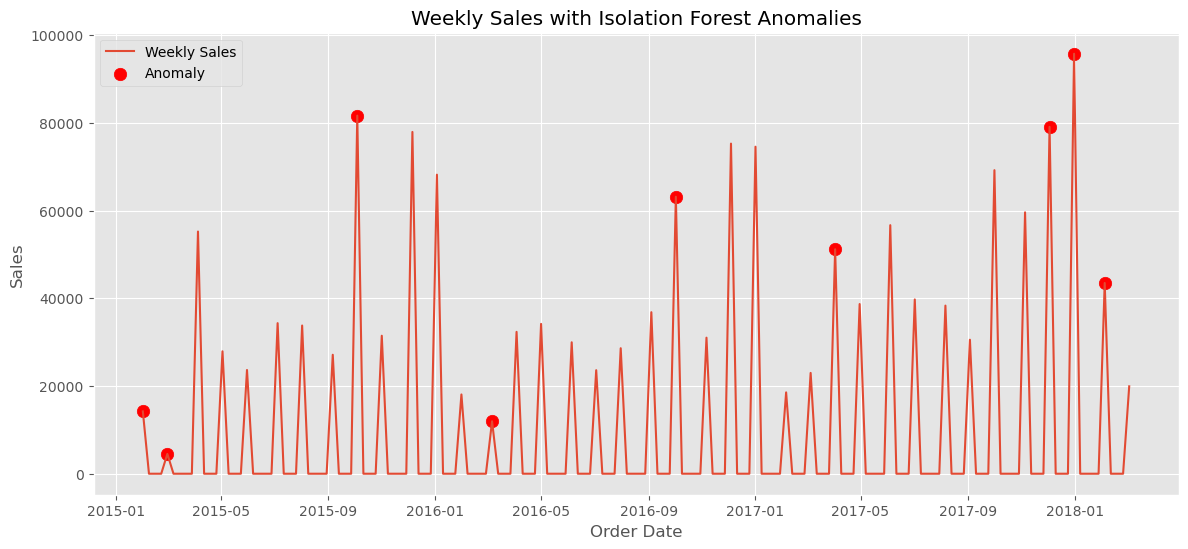

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)

anomalies = weekly_sales[weekly_sales["Anomaly"] == -1]

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Weekly Sales with Isolation Forest Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig("charts/isolation_forest_anomalies.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np

weekly_sales["Rolling Mean"] = weekly_sales["Sales"].rolling(window=4).mean()
weekly_sales["Rolling Std"] = weekly_sales["Sales"].rolling(window=4).std()

weekly_sales["Z-Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling Mean"])
    / weekly_sales["Rolling Std"]
)

weekly_sales["Z_Anomaly"] = np.where(
    abs(weekly_sales["Z-Score"]) > 2,
    1,
    0
)

weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly
0,2015-02-01,14205.707,-1,NaN,NaN,NaN,0
1,2015-02-08,0.000,1,NaN,NaN,NaN,0
2,2015-02-15,0.000,1,NaN,NaN,NaN,0
3,2015-02-22,0.000,1,3551.42675,7102.8535,-0.5,0
4,2015-03-01,4519.892,-1,1129.97300,2259.9460,1.5,0


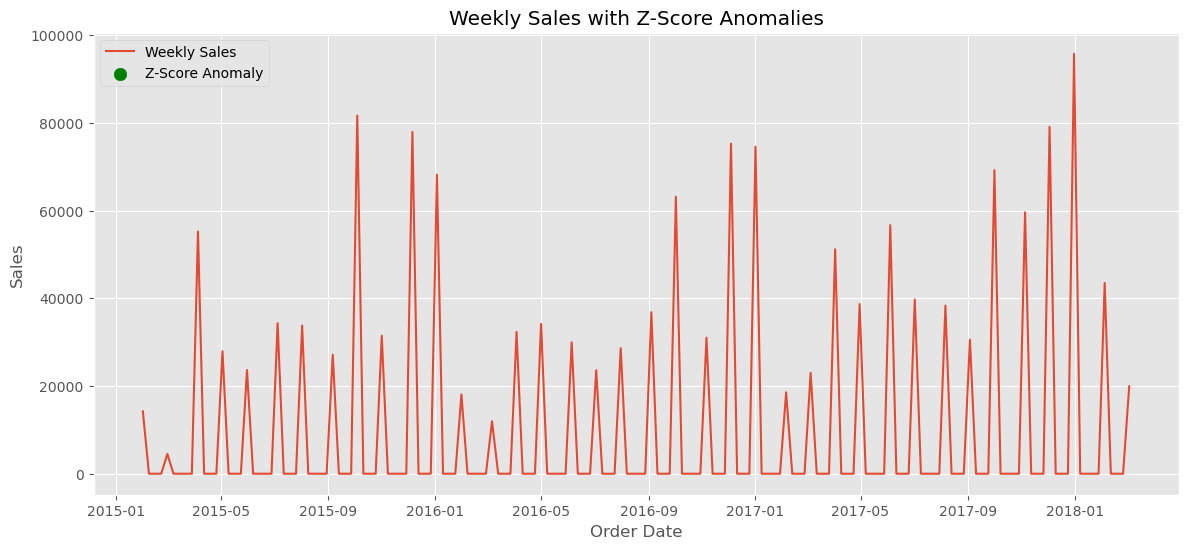

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)

z_anomalies = weekly_sales[weekly_sales["Z_Anomaly"] == 1]

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales with Z-Score Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- Isolation Forest detected unusual weekly sales based on data distribution.
- Z-Score detected anomalies where sales deviated more than two standard deviations from the rolling mean.
- Some anomalies were detected by both methods, while others differed due to their underlying detection techniques.
- Using both approaches provides a more reliable anomaly detection strategy.

## Possible Real-World Explanation of Detected Anomalies

- Extremely high sales weeks may correspond to seasonal promotions, festive shopping periods, or increased customer demand.
- Unusually low sales weeks may be caused by off-season demand, inventory shortages, or reduced customer activity.
- Sudden spikes may also occur because of bulk corporate orders or successful marketing campaigns.
- Isolation Forest and Z-Score identify abnormal sales behaviour using different statistical approaches, so some anomalies are detected by both methods while others are unique to one method.


# Task 6 – Product Demand Segmentation using K-Means Clustering

In [ ]:
# Aggregate data at Sub-Category level

product_features = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Avg_Order_Value=("Sales", "mean"),
    Sales_Volatility=("Sales", "std")
).reset_index()

product_features.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


In [ ]:
# Calculate Year-over-Year Growth for each Sub-Category

growth = df.groupby(["Sub-Category", "Year"])["Sales"].sum().reset_index()

growth["Growth_Rate"] = growth.groupby("Sub-Category")["Sales"].pct_change()

growth = growth.groupby("Sub-Category")["Growth_Rate"].mean().reset_index()

growth.head()

,Sub-Category,Growth_Rate
0,Accessories,0.376381
1,Appliances,0.399276
2,Art,0.166056
3,Binders,0.218736
4,Bookcases,0.238065


In [ ]:
# Merge Growth Rate with Product Features

product_features = product_features.merge(
    growth,
    on="Sub-Category",
    how="left"
)

product_features.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate
0,Accessories,164186.7000,217.178175,337.723800,0.376381
1,Appliances,104618.4030,227.926804,378.006735,0.399276
2,Art,26705.4100,34.019631,60.301752,0.166056
3,Binders,200028.7850,134.067550,568.099970,0.218736
4,Bookcases,113813.1987,503.598224,641.419280,0.238065


In [ ]:
from sklearn.preprocessing import StandardScaler

features = product_features[
    ["Total_Sales", "Avg_Order_Value", "Sales_Volatility", "Growth_Rate"]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.31598599, -0.36354857, -0.36820849,  0.11450548],
       [-0.28817617, -0.34520236, -0.32287389,  0.16628324],
       [-1.07839653, -0.67617125, -0.68042053, -0.36114889],
       [ 0.67950874, -0.50540527, -0.1089421 , -0.24201087],
       [-0.19491939,  0.12532518, -0.02642822, -0.19829775]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

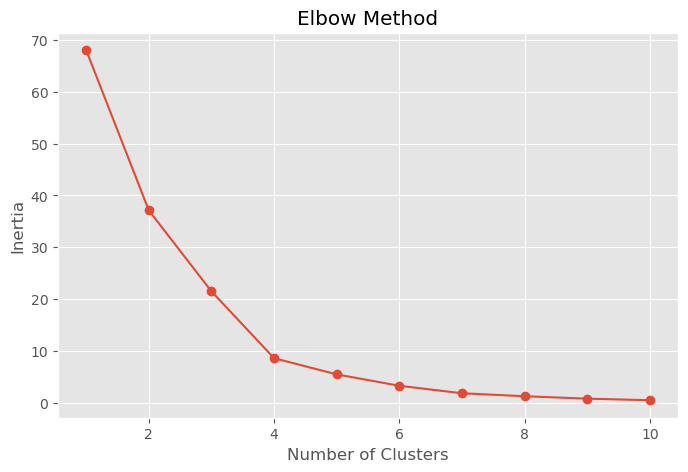

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

os.makedirs("charts", exist_ok=True)

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Apply K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(scaled_features)

product_features.head()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
0,Accessories,164186.7000,217.178175,337.723800,0.376381,2
1,Appliances,104618.4030,227.926804,378.006735,0.399276,1
2,Art,26705.4100,34.019631,60.301752,0.166056,1
3,Binders,200028.7850,134.067550,568.099970,0.218736,2
4,Bookcases,113813.1987,503.598224,641.419280,0.238065,1


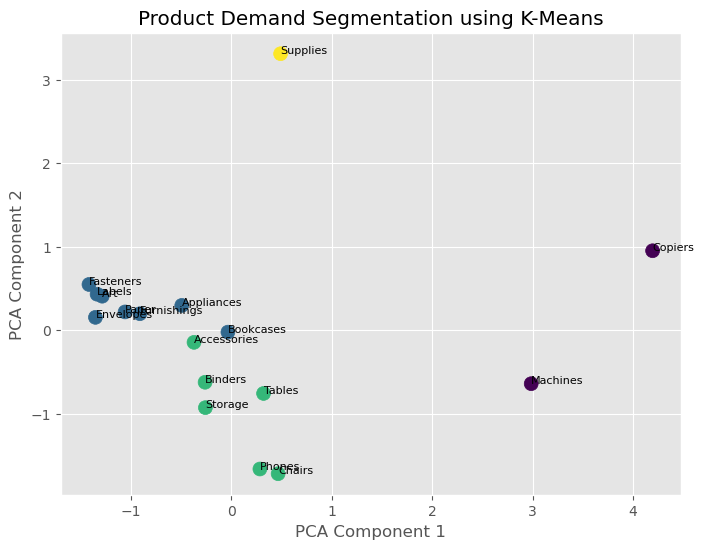

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# Reduce features to 2 dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

product_features["PCA1"] = pca_features[:, 0]
product_features["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(8,6))

plt.scatter(
    product_features["PCA1"],
    product_features["PCA2"],
    c=product_features["Cluster"],
    s=100
)

for i in range(len(product_features)):
    plt.text(
        product_features["PCA1"][i],
        product_features["PCA2"][i],
        product_features["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

os.makedirs("charts", exist_ok=True)

plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
product_features

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PCA1,PCA2
0,Accessories,164186.7000,217.178175,337.723800,0.376381,2,-0.369152,-0.146390
1,Appliances,104618.4030,227.926804,378.006735,0.399276,1,-0.490906,0.296120
2,Art,26705.4100,34.019631,60.301752,0.166056,1,-1.282601,0.406386
3,Binders,200028.7850,134.067550,568.099970,0.218736,2,-0.258919,-0.624599
4,Bookcases,113813.1987,503.598224,641.419280,0.238065,1,-0.031793,-0.024216
5,Chairs,322822.7310,531.833165,551.180296,0.071358,2,0.467755,-1.720204
6,Copiers,146248.0940,2215.880212,3216.185499,0.846718,0,4.194037,0.950565
7,Envelopes,16128.0460,65.032444,85.170691,-0.027666,1,-1.349906,0.153063
8,Fasteners,3001.9600,14.027850,12.466864,0.157034,1,-1.414423,0.546838
9,Furnishings,89212.0180,95.823865,148.421490,0.287889,1,-0.907680,0.196361


### Observations

- The Elbow Method indicated that 4 clusters were suitable for product demand segmentation.
- Products were grouped based on Total Sales, Average Order Value, Sales Volatility, and Growth Rate.
- High-value products such as Copiers and Machines formed separate clusters because of their high average order value.
- Supplies showed exceptionally high growth and formed an independent cluster.
- The clustering results can help businesses design different inventory and stocking strategies for different product groups.

In [ ]:
# Display products in each cluster

product_features.groupby("Cluster")["Sub-Category"].apply(list)

Cluster
0                                  [Copiers, Machines]
1    [Appliances, Art, Bookcases, Envelopes, Fasten...
2    [Accessories, Binders, Chairs, Phones, Storage...
3                                           [Supplies]
Name: Sub-Category, dtype: object

### Cluster Interpretation

**Cluster 0 – High Value Products**
- Copiers
- Machines

These products have a high average order value and require careful inventory planning.

---

**Cluster 1 – Stable Demand Products**
- Appliances
- Art
- Bookcases
- Envelopes
- Fasteners
- Furnishings
- Labels
- Paper

These products show relatively stable demand and should be stocked regularly.

---

**Cluster 2 – High Volume Products**
- Accessories
- Binders
- Chairs
- Phones
- Storage
- Tables

These products generate high sales volume and require continuous inventory replenishment.

---

**Cluster 3 – Growing Demand Products**
- Supplies

This product category shows the highest growth rate and should be monitored for increasing future demand.

## Stocking Strategy Recommendations

- **Cluster 0 – High Value Products:** Maintain controlled inventory because these products have a high average order value.

- **Cluster 1 – Stable Demand Products:** Maintain regular inventory levels with periodic replenishment.

- **Cluster 2 – High Volume Products:** Keep higher inventory levels and replenish stock frequently to avoid stock shortages.

- **Cluster 3 – Growing Demand Products:** Increase inventory gradually to support future demand.

# Supplementary Dataset Analysis (Video Game Sales)

To demonstrate multi-source data analysis, the Video Game Sales dataset was incorporated as a supplementary dataset. This dataset was explored to understand sales patterns across another industry and to compare anomaly detection techniques with the retail sales dataset.

In [ ]:
import pandas as pd

vg = pd.read_csv("vgsales.csv")

vg.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
vg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
vg.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [ ]:
vg.duplicated().sum()

np.int64(0)

### Observations

- The supplementary Video Game Sales dataset contains **16,598 records** and **11 columns**.
- The dataset includes game details such as platform, genre, publisher, release year, and regional/global sales.
- The **Year** column contains **271 missing values**, while the **Publisher** column contains **58 missing values**.
- No duplicate records were found in the dataset.
- The dataset is suitable for performing additional sales analysis and anomaly detection.

In [ ]:
# Year-wise Global Sales

vg_yearly = vg.groupby("Year")["Global_Sales"].sum().reset_index()

vg_yearly.head()

,Year,Global_Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


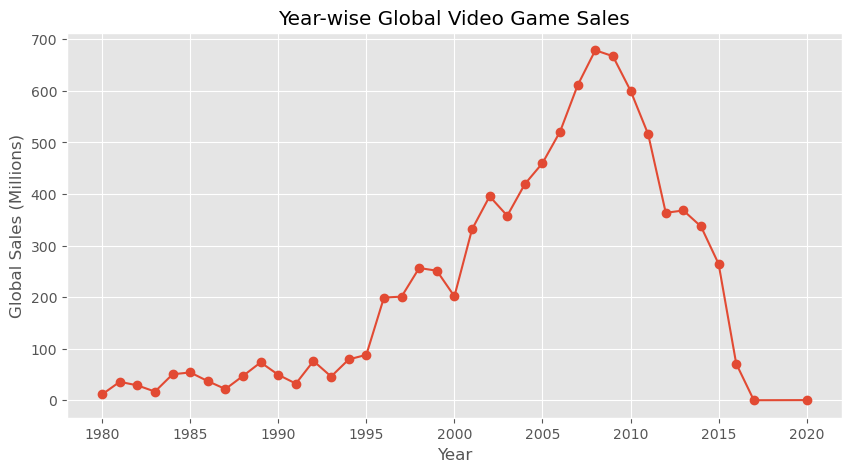

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(vg_yearly["Year"], vg_yearly["Global_Sales"], marker="o")
plt.title("Year-wise Global Video Game Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(True)

plt.savefig("charts/video_game_sales_trend.png")
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

iso_vg = IsolationForest(
    contamination=0.05,
    random_state=42
)

vg_yearly["Anomaly"] = iso_vg.fit_predict(vg_yearly[["Global_Sales"]])

vg_yearly.head()

,Year,Global_Sales,Anomaly
0,1980.0,11.38,1
1,1981.0,35.77,1
2,1982.0,28.86,1
3,1983.0,16.79,1
4,1984.0,50.36,1


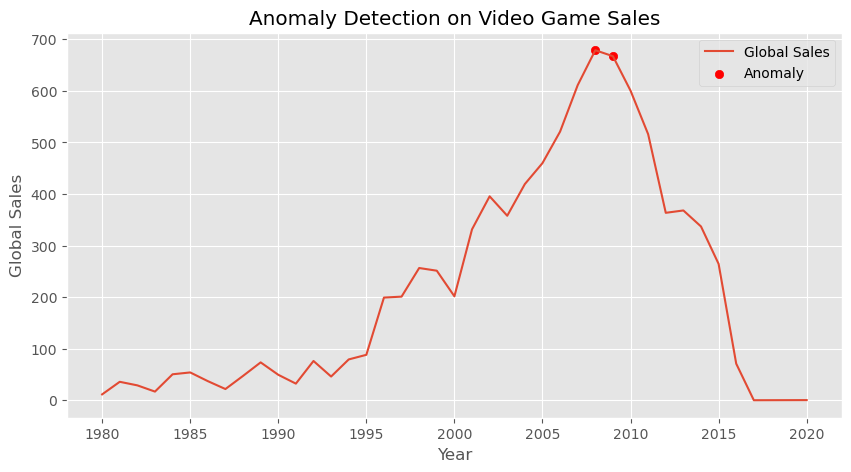

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    vg_yearly["Year"],
    vg_yearly["Global_Sales"],
    label="Global Sales"
)

plt.scatter(
    vg_yearly[vg_yearly["Anomaly"]==-1]["Year"],
    vg_yearly[vg_yearly["Anomaly"]==-1]["Global_Sales"],
    color="red",
    label="Anomaly"
)

plt.title("Anomaly Detection on Video Game Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales")

plt.legend()

plt.savefig("charts/video_game_anomalies.png")

plt.show()

### Multi-Source Analysis

The supplementary Video Game Sales dataset was analyzed alongside the Superstore retail dataset to demonstrate multi-source analytical capability.

Key observations:

- The Superstore dataset focuses on retail transactions across categories and regions, whereas the Video Game Sales dataset represents annual global sales across the gaming industry.
- Isolation Forest successfully identified unusual sales periods in both datasets, demonstrating that anomaly detection techniques can generalize across different business domains.
- The supplementary dataset validates that the proposed analytical workflow is adaptable to multiple industries and is not limited to retail sales forecasting.